架構(benchmark Logistic Regression): <br>
1. Without Feature Selection and SMOTE
2. Without Feature Selection but with SMOTE
3. SMOTE+Feature Selection with LASSO

In [1]:
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', None) 

In [3]:
df = pd.read_csv('clean_data.csv', low_memory=False)

In [5]:
df.shape

(56741, 291)

In [9]:
df.head()

,gvkey,datadate,sic,dummy_costat,tic,conm,aco,acoxar,act,artfs,at,ceq,clt,dlc,dltt,dptb,dptc,esopct,esopt,iali,ialti,iasti,iatci,iati,iatmi,iaui,icapt,intan,invt,islt,ist,istc,istm,isut,ivpt,ivst,lcabg,lcat,lco,lcoxar,lct,lcuacu,llot,lo,lse,lt,mrct,npat,ppegt,ppent,prvt,pstk,pvt,rati,rect,ret,rlt,rvbti,rvdt,rveqt,rvnt,rvti,srt,tdst,tstk,txndb,uceq,batr,bcltbl,bct,bctr,bltbl,cgti,citotal,cnltbl,dvt,gptbl,idit,initb,iptbl,ipti,isgt,ivi,nit,nits,opiti,patr,pctr,pltbl,pnlbl,ppptbl,ptbl,revt,tie,tii,txt,uopi,utme,xagt,xint,xlr,xnitb,xopr,xt,xuwti,fopt,fsrct,fuset,PERMNO,delist date,delist year,year,dummy_delist,dummy_delistconm,sic_rank,dummy_100,dummy_200,dummy_700,dummy_800,dummy_1000,dummy_1200,dummy_1300,dummy_1400,dummy_1500,dummy_1600,dummy_1700,dummy_2000,dummy_2100,dummy_2200,dummy_2300,dummy_2400,dummy_2500,dummy_2600,dummy_2700,dummy_2800,dummy_2900,dummy_3000,dummy_3100,dummy_3200,dummy_3300,dummy_3400,dummy_3500,dummy_3600,dummy_3700,dummy_3800,dummy_3900,dummy_4000,dummy_4100,dummy_4200,dummy_4400,dummy_4500,dummy_4600,dummy_4700,dummy_4800,dummy_4900,dummy_5000,dummy_5100,dummy_5200,dummy_5300,dummy_5400,dummy_5500,dummy_5600,dummy_5700,dummy_5800,dummy_5900,dummy_6000,dummy_6100,dummy_6200,dummy_6300,dummy_6400,dummy_6500,dummy_6700,dummy_7000,dummy_7200,dummy_7300,dummy_7500,dummy_7600,dummy_7800,dummy_7900,dummy_8000,dummy_8100,dummy_8200,dummy_8300,dummy_8700,dummy_8900,dummy_9900,dummy_aco_missing,dummy_acoxar_missing,dummy_act_missing,dummy_artfs_missing,dummy_at_missing,dummy_ceq_missing,dummy_clt_missing,dummy_dlc_missing,dummy_dltt_missing,dummy_dptb_missing,dummy_dptc_missing,dummy_esopct_missing,dummy_esopt_missing,dummy_iali_missing,dummy_ialti_missing,dummy_iasti_missing,dummy_iatci_missing,dummy_iati_missing,dummy_iatmi_missing,dummy_iaui_missing,dummy_icapt_missing,dummy_intan_missing,dummy_invt_missing,dummy_islt_missing,dummy_ist_missing,dummy_istc_missing,dummy_istm_missing,dummy_isut_missing,dummy_ivpt_missing,dummy_ivst_missing,dummy_lcabg_missing,dummy_lcat_missing,dummy_lco_missing,dummy_lcoxar_missing,dummy_lct_missing,dummy_lcuacu_missing,dummy_llot_missing,dummy_lo_missing,dummy_lse_missing,dummy_lt_missing,dummy_mrct_missing,dummy_npat_missing,dummy_ppegt_missing,dummy_ppent_missing,dummy_prvt_missing,dummy_pstk_missing,dummy_pvt_missing,dummy_rati_missing,dummy_rect_missing,dummy_ret_missing,dummy_rlt_missing,dummy_rvbti_missing,dummy_rvdt_missing,dummy_rveqt_missing,dummy_rvnt_missing,dummy_rvti_missing,dummy_srt_missing,dummy_tdst_missing,dummy_tstk_missing,dummy_txndb_missing,dummy_uceq_missing,dummy_batr_missing,dummy_bcltbl_missing,dummy_bct_missing,dummy_bctr_missing,dummy_bltbl_missing,dummy_cgti_missing,dummy_citotal_missing,dummy_cnltbl_missing,dummy_dvt_missing,dummy_gptbl_missing,dummy_idit_missing,dummy_initb_missing,dummy_iptbl_missing,dummy_ipti_missing,dummy_isgt_missing,dummy_ivi_missing,dummy_nit_missing,dummy_nits_missing,dummy_opiti_missing,dummy_patr_missing,dummy_pctr_missing,dummy_pltbl_missing,dummy_pnlbl_missing,dummy_ppptbl_missing,dummy_ptbl_missing,dummy_revt_missing,dummy_tie_missing,dummy_tii_missing,dummy_txt_missing,dummy_uopi_missing,dummy_utme_missing,dummy_xagt_missing,dummy_xint_missing,dummy_xlr_missing,dummy_xnitb_missing,dummy_xopr_missing,dummy_xt_missing,dummy_xuwti_missing,dummy_fopt_missing,dummy_fsrct_missing,dummy_fuset_missing,dummy_PERMNO_missing,dummy_delist date_missing,dummy_delist year_missing
0,1004,2019-05-31,5080,0,AIR,AAR CORP,4.492001,NaN,6.860139,NaN,7.325281,11.810300,NaN,0.000000,4.960745,NaN,NaN,6.675823,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.117370,4.987708,6.380123,NaN,NaN,NaN,NaN,NaN,NaN,3.034953,NaN,NaN,5.139908,NaN,5.881929,NaN,NaN,4.739885,7.325281,6.417222,4.414010,NaN,6.365783,5.857362,NaN,5.46806,NaN,NaN,5.553630,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.749138,11.782976,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.659318,NaN,6.578557,NaN,2.833213,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.276060,NaN,NaN,9.050512,NaN,NaN,NaN,8.2386

In [15]:
# 方法1: 選取所有非數值型的欄位
# np.number 包含了所有數值型別 (int, float, complex)
non_numeric_cols_df = df.select_dtypes(exclude=np.number)

# 如果您想排除更廣泛的類型，例如也排除布林值和日期時間，可以這樣做：
# non_numeric_cols_df = df.select_dtypes(exclude=['number', 'bool', 'datetime'])

print("非數值型的 DataFrame：")
print(non_numeric_cols_df)
print("-" * 30)

print("非數值型欄位的名稱：")
print(non_numeric_cols_df.columns.tolist())

非數值型的 DataFrame：
         datadate   tic                         conm delist date
0      2019-05-31   AIR                     AAR CORP         NaN
1      2020-05-31   AIR                     AAR CORP         NaN
2      2021-05-31   AIR                     AAR CORP         NaN
3      2022-05-31   AIR                     AAR CORP         NaN
4      2023-05-31   AIR                     AAR CORP         NaN
...           ...   ...                          ...         ...
56736  2024-12-31  INDP    INDAPTUS THERAPEUTICS INC         NaN
56737  2023-12-31  BEMB  ISHARES JP MORGAN B U E M B         NaN
56738  2024-12-31  BEMB  ISHARES JP MORGAN B U E M B         NaN
56739  2023-12-31   TIC                  ACUREN CORP         NaN
56740  2024-12-31   TIC                  ACUREN CORP         NaN

[56741 rows x 4 columns]
------------------------------
非數值型欄位的名稱：
['datadate', 'tic', 'conm', 'delist date']


In [7]:
# 跑 LR前先 drop 非數值的欄位
# 移除和 delist 相關的欄位以免透露給模型非財務資訊：'conm','sic_rank','dummy_PERMNO_missing',
 #              'dummy_delist date_missing','dummy_delist year_missing'
exclude_list = ['gvkey', 'datadate', 'sic', 'PERMNO', 'delist date', 'delist year', 'tic', 'conm','sic_rank','dummy_PERMNO_missing',
              'dummy_delist date_missing','dummy_delist year_missing']
#exclude_list = ['gvkey', 'datadate', 'sic', 'PERMNO', 'delist date', 'delist year', 'tic', 'conm','sic_rank']
data=df.drop(exclude_list,axis=1)

In [19]:
data.head()

,dummy_costat,aco,acoxar,act,artfs,at,ceq,clt,dlc,dltt,dptb,dptc,esopct,esopt,iali,ialti,iasti,iatci,iati,iatmi,iaui,icapt,intan,invt,islt,ist,istc,istm,isut,ivpt,ivst,lcabg,lcat,lco,lcoxar,lct,lcuacu,llot,lo,lse,lt,mrct,npat,ppegt,ppent,prvt,pstk,pvt,rati,rect,ret,rlt,rvbti,rvdt,rveqt,rvnt,rvti,srt,tdst,tstk,txndb,uceq,batr,bcltbl,bct,bctr,bltbl,cgti,citotal,cnltbl,dvt,gptbl,idit,initb,iptbl,ipti,isgt,ivi,nit,nits,opiti,patr,pctr,pltbl,pnlbl,ppptbl,ptbl,revt,tie,tii,txt,uopi,utme,xagt,xint,xlr,xnitb,xopr,xt,xuwti,fopt,fsrct,fuset,year,dummy_delist,dummy_delistconm,dummy_100,dummy_200,dummy_700,dummy_800,dummy_1000,dummy_1200,dummy_1300,dummy_1400,dummy_1500,dummy_1600,dummy_1700,dummy_2000,dummy_2100,dummy_2200,dummy_2300,dummy_2400,dummy_2500,dummy_2600,dummy_2700,dummy_2800,dummy_2900,dummy_3000,dummy_3100,dummy_3200,dummy_3300,dummy_3400,dummy_3500,dummy_3600,dummy_3700,dummy_3800,dummy_3900,dummy_4000,dummy_4100,dummy_4200,dummy_4400,dummy_4500,dummy_4600,dummy_4700,dummy_4800,dummy_4900,dummy_5000,dummy_5100,dummy_5200,dummy_5300,dummy_5400,dummy_5500,dummy_5600,dummy_5700,dummy_5800,dummy_5900,dummy_6000,dummy_6100,dummy_6200,dummy_6300,dummy_6400,dummy_6500,dummy_6700,dummy_7000,dummy_7200,dummy_7300,dummy_7500,dummy_7600,dummy_7800,dummy_7900,dummy_8000,dummy_8100,dummy_8200,dummy_8300,dummy_8700,dummy_8900,dummy_9900,dummy_aco_missing,dummy_acoxar_missing,dummy_act_missing,dummy_artfs_missing,dummy_at_missing,dummy_ceq_missing,dummy_clt_missing,dummy_dlc_missing,dummy_dltt_missing,dummy_dptb_missing,dummy_dptc_missing,dummy_esopct_missing,dummy_esopt_missing,dummy_iali_missing,dummy_ialti_missing,dummy_iasti_missing,dummy_iatci_missing,dummy_iati_missing,dummy_iatmi_missing,dummy_iaui_missing,dummy_icapt_missing,dummy_intan_missing,dummy_invt_missing,dummy_islt_missing,dummy_ist_missing,dummy_istc_missing,dummy_istm_missing,dummy_isut_missing,dummy_ivpt_missing,dummy_ivst_missing,dummy_lcabg_missing,dummy_lcat_missing,dummy_lco_missing,dummy_lcoxar_missing,dummy_lct_missing,dummy_lcuacu_missing,dummy_llot_missing,dummy_lo_missing,dummy_lse_missing,dummy_lt_missing,dummy_mrct_missing,dummy_npat_missing,dummy_ppegt_missing,dummy_ppent_missing,dummy_prvt_missing,dummy_pstk_missing,dummy_pvt_missing,dummy_rati_missing,dummy_rect_missing,dummy_ret_missing,dummy_rlt_missing,dummy_rvbti_missing,dummy_rvdt_missing,dummy_rveqt_missing,dummy_rvnt_missing,dummy_rvti_missing,dummy_srt_missing,dummy_tdst_missing,dummy_tstk_missing,dummy_txndb_missing,dummy_uceq_missing,dummy_batr_missing,dummy_bcltbl_missing,dummy_bct_missing,dummy_bctr_missing,dummy_bltbl_missing,dummy_cgti_missing,dummy_citotal_missing,dummy_cnltbl_missing,dummy_dvt_missing,dummy_gptbl_missing,dummy_idit_missing,dummy_initb_missing,dummy_iptbl_missing,dummy_ipti_missing,dummy_isgt_missing,dummy_ivi_missing,dummy_nit_missing,dummy_nits_missing,dummy_opiti_missing,dummy_patr_missing,dummy_pctr_missing,dummy_pltbl_missing,dummy_pnlbl_missing,dummy_ppptbl_missing,dummy_ptbl_missing,dummy_revt_missing,dummy_tie_missing,dummy_tii_missing,dummy_txt_missing,dummy_uopi_missing,dummy_utme_missing,dummy_xagt_missing,dummy_xint_missing,dummy_xlr_missing,dummy_xnitb_missing,dummy_xopr_missing,dummy_xt_missing,dummy_xuwti_missing,dummy_fopt_missing,dummy_fsrct_missing,dummy_fuset_missing
0,0,4.492001,NaN,6.860139,NaN,7.325281,11.810300,NaN,0.000000,4.960745,NaN,NaN,6.675823,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,11.117370,4.987708,6.380123,NaN,NaN,NaN,NaN,NaN,NaN,3.034953,NaN,NaN,5.139908,NaN,5.881929,NaN,NaN,4.739885,7.325281,6.417222,4.414010,NaN,6.365783,5.857362,NaN,5.46806,NaN,NaN,5.553630,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.749138,11.782976,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10.659318,NaN,6.578557,NaN,2.833213,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.276060,NaN,NaN,9.050512,NaN,NaN,NaN,8.238669,NaN,NaN,7.671501,NaN,NaN,NaN,NaN,NaN,2019,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,

In [9]:
data.shape

(56741, 279)

In [11]:
# 按時間分測試集2024和訓練集2019-2023
X = data.drop(columns=['dummy_delistconm'])# 特徵欄位 測試集2024
y = data['dummy_delistconm']

# 根據年代分割
X_train = X[data['year'].between(2019, 2023)]
y_train = y[data['year'].between(2019, 2023)]

X_test = X[data['year'] == 2024]
y_test = y[data['year'] == 2024]

# 確認分割結果
print("訓練集大小:", X_train.shape, "測試集大小:", X_test.shape)

訓練集大小: (46960, 278) 測試集大小: (9781, 278)


#### 1.Without Feature Selection and SMOTE

In [43]:
# 建立模型
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)

In [45]:
#用 中位數""補 missing value
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='median')  
X_train_imputed = imputer.fit_transform(X_train)
X_test_imputed = imputer.transform(X_test)
model.fit(X_train_imputed, y_train)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [47]:
from sklearn.metrics import accuracy_score, classification_report

# 預測
y_pred = model.predict(X_test_imputed)

# 評估
accuracy = accuracy_score(y_test, y_pred)
print("準確度:", accuracy)
print("分類報告:\n", classification_report(y_test, y_pred))

準確度: 0.9988753706165013
分類報告:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00      9769
           1       0.67      0.17      0.27        12

    accuracy                           1.00      9781
   macro avg       0.83      0.58      0.63      9781
weighted avg       1.00      1.00      1.00      9781



Step1：進行預測（二分類模型）

In [49]:
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve

# 預測概率（用於AUC）
y_pred_proba = model.predict_proba(X_test_imputed)[:, 1]

# 預測類別（用於混淆矩陣）
y_pred = model.predict(X_test_imputed)

Step2：畫出混淆矩陣

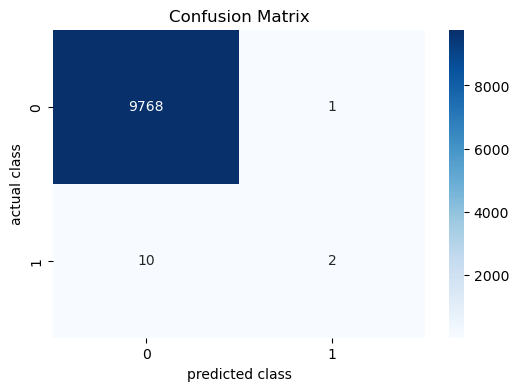

In [51]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

# 繪製熱度圖
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('predicted class')
plt.ylabel('actual class')
plt.title('Confusion Matrix')
plt.show()

Step3：計算並印出AUC值（區分能力）

In [53]:
from sklearn.metrics import roc_auc_score

auc_score = roc_auc_score(y_test, y_pred_proba)
print(f'AUC (Area Under Curve): {auc_score:.3f}')

AUC (Area Under Curve): 0.908


畫 ROC Curve（Receiver Operating Characteristic）

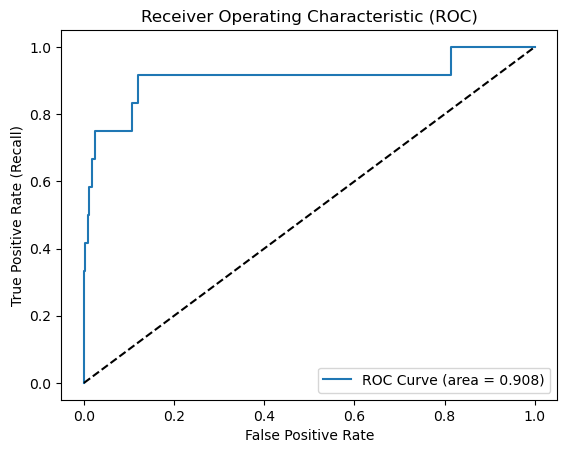

In [55]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure()
plt.plot(fpr, tpr, label=f'ROC Curve (area = {auc_score:.3f})')
plt.plot([0,1], [0,1], 'k--')  # 其他指標：對角線（隨機預測）
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc='lower right')
plt.show()

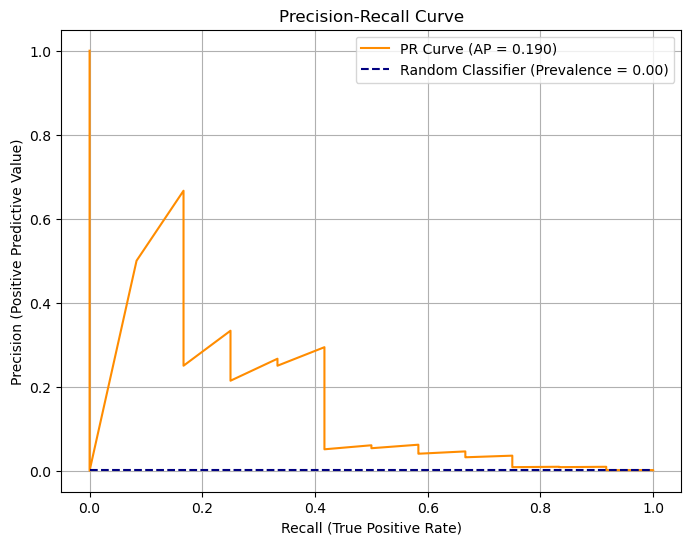

Average Precision (AP) Score: 0.190


In [57]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# --- 2. 獲取 Precision、Recall 和 Thresholds ---
# precision_recall_curve 函數返回 precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

# 計算平均精準度 (Average Precision, AP)，這是 PR 曲線的 AUC
ap_score = average_precision_score(y_test, y_pred_proba)

# --- 3. 繪製 PR 曲線 ---
plt.figure(figsize=(8, 6))

# 繪製 PR 曲線
# 注意：X 軸是 Recall，Y 軸是 Precision
plt.plot(recall, precision, label=f'PR Curve (AP = {ap_score:.3f})', color='darkorange')

# 繪製隨機分類器的基準線
# 隨機分類器的 Precision 等於正類別的比例 (Prevalence)
no_skill_prevalence = sum(y_test == 1) / len(y_test)
plt.plot([0, 1], [no_skill_prevalence, no_skill_prevalence], linestyle='--', color='navy', label=f'Random Classifier (Prevalence = {no_skill_prevalence:.2f})')


plt.xlabel('Recall (True Positive Rate)') # X 軸是召回率
plt.ylabel('Precision (Positive Predictive Value)') # Y 軸是精準率
plt.title('Precision-Recall Curve') # 圖表標題
plt.legend(loc='best') # 放置圖例在最佳位置
plt.grid(True) # 顯示網格
plt.show()

print(f"Average Precision (AP) Score: {ap_score:.3f}")


#### 2. Without Feature Selection but with SMOTE

In [13]:
X_train = X_train.replace([np.inf, -np.inf], np.nan).fillna(X_train.median())
X_test  = X_test.replace([np.inf, -np.inf], np.nan).fillna(X_train.median())

In [15]:
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE

In [17]:
print("Before SMOTE:", Counter(y_train))
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_train, y_train)
print("After SMOTE:", Counter(y_res))

Before SMOTE: Counter({0: 46742, 1: 218})
After SMOTE: Counter({0: 46742, 1: 46742})


In [54]:
scaler = StandardScaler()
X_res_scaled = scaler.fit_transform(X_res)
X_test_scaled = scaler.transform(X_test)

In [56]:
# 建立模型
from sklearn.linear_model import LogisticRegression
model_smote_scaled = LogisticRegression(max_iter=1000)
model_smote_scaled.fit(X_res_scaled,y_res)

LogisticRegression(max_iter=1000)


Accuracy: 0.9844596667007464
AUC: 0.9550875217524823

Classification Report:
               precision    recall  f1-score   support

           0     0.9995    0.9850    0.9922      9769
           1     0.0455    0.5833    0.0843        12

    accuracy                         0.9845      9781
   macro avg     0.5225    0.7841    0.5383      9781
weighted avg     0.9983    0.9845    0.9910      9781



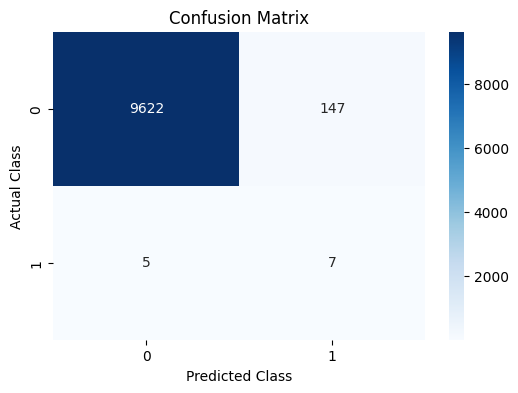

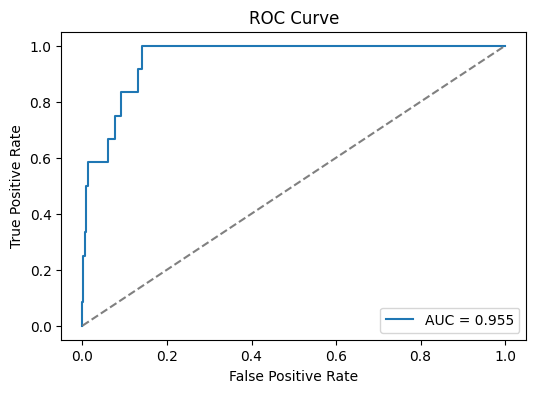

In [60]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = model_smote_scaled.predict(X_test_scaled )
y_prob = model_smote_scaled.predict_proba(X_test_scaled)[:, 1]

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix')
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

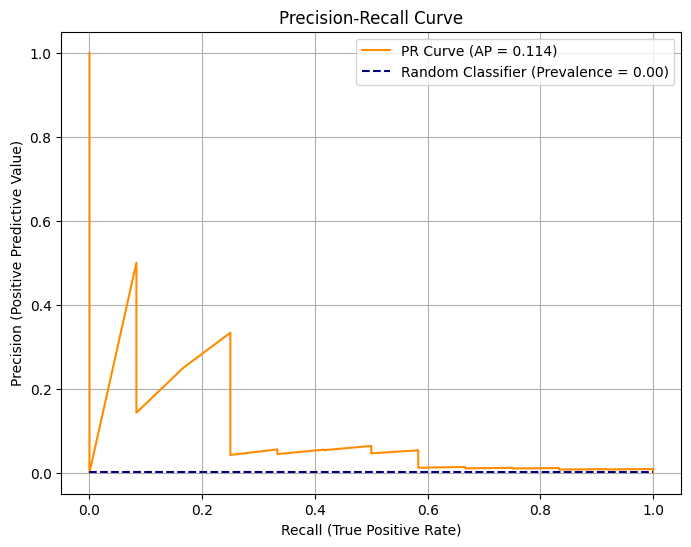

Average Precision (AP) Score: 0.114


In [62]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# --- 2. 獲取 Precision、Recall 和 Thresholds ---
# precision_recall_curve 函數返回 precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# 計算平均精準度 (Average Precision, AP)，這是 PR 曲線的 AUC
ap_score = average_precision_score(y_test, y_prob)

# --- 3. 繪製 PR 曲線 ---
plt.figure(figsize=(8, 6))

# 繪製 PR 曲線
# 注意：X 軸是 Recall，Y 軸是 Precision
plt.plot(recall, precision, label=f'PR Curve (AP = {ap_score:.3f})', color='darkorange')

# 繪製隨機分類器的基準線
# 隨機分類器的 Precision 等於正類別的比例 (Prevalence)
no_skill_prevalence = sum(y_test == 1) / len(y_test)
plt.plot([0, 1], [no_skill_prevalence, no_skill_prevalence], linestyle='--', color='navy', label=f'Random Classifier (Prevalence = {no_skill_prevalence:.2f})')


plt.xlabel('Recall (True Positive Rate)') # X 軸是召回率
plt.ylabel('Precision (Positive Predictive Value)') # Y 軸是精準率
plt.title('Precision-Recall Curve') # 圖表標題
plt.legend(loc='best') # 放置圖例在最佳位置
plt.grid(True) # 顯示網格
plt.show()

print(f"Average Precision (AP) Score: {ap_score:.3f}")

#### 3. SMOTE+Feature Selection with LASSO

In [19]:
scaler = StandardScaler()
X_res_scaled = scaler.fit_transform(X_res)
X_test_scaled = scaler.transform(X_test)

In [21]:
lasso_selector = LogisticRegression( #跑有點久
    penalty='l1',
    solver='saga',
    C=0.01,        # smaller → stronger regularization
    max_iter=3000,
    random_state=42
)
lasso_selector.fit(X_res_scaled, y_res)

# retain features with nonzero coefficients
selected_mask = lasso_selector.coef_[0] != 0
selected_features = X.columns[selected_mask]
print(f"Selected features ({len(selected_features)}): {list(selected_features)}")

# reduce data
X_res_selected = X_res_scaled[:, selected_mask]
X_test_selected = X_test_scaled[:, selected_mask]

Selected features (129): ['dummy_costat', 'aco', 'act', 'artfs', 'ceq', 'dlc', 'dltt', 'dptc', 'esopt', 'ialti', 'icapt', 'intan', 'invt', 'ivpt', 'ivst', 'lco', 'lcuacu', 'npat', 'pvt', 'rect', 'ret', 'rvdt', 'rveqt', 'dvt', 'idit', 'revt', 'uopi', 'xint', 'xlr', 'xopr', 'year', 'dummy_delist', 'dummy_100', 'dummy_200', 'dummy_700', 'dummy_800', 'dummy_1000', 'dummy_1200', 'dummy_1300', 'dummy_1400', 'dummy_1500', 'dummy_1600', 'dummy_1700', 'dummy_2000', 'dummy_2100', 'dummy_2200', 'dummy_2300', 'dummy_2400', 'dummy_2500', 'dummy_2600', 'dummy_2700', 'dummy_2800', 'dummy_2900', 'dummy_3000', 'dummy_3100', 'dummy_3200', 'dummy_3300', 'dummy_3400', 'dummy_3500', 'dummy_3600', 'dummy_3700', 'dummy_3800', 'dummy_3900', 'dummy_4000', 'dummy_4100', 'dummy_4200', 'dummy_4400', 'dummy_4500', 'dummy_4600', 'dummy_4700', 'dummy_4800', 'dummy_4900', 'dummy_5000', 'dummy_5100', 'dummy_5300', 'dummy_5400', 'dummy_5500', 'dummy_5600', 'dummy_5700', 'dummy_5800', 'dummy_5900', 'dummy_6000', 'dummy_

In [27]:
# 建立模型
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(max_iter=1000)
model.fit(X_res_selected, y_res)

LogisticRegression(max_iter=1000)


Accuracy: 0.9829260811777937
AUC: 0.9625430784454225

Classification Report:
               precision    recall  f1-score   support

           0     0.9995    0.9834    0.9914      9769
           1     0.0414    0.5833    0.0773        12

    accuracy                         0.9829      9781
   macro avg     0.5204    0.7834    0.5344      9781
weighted avg     0.9983    0.9829    0.9903      9781



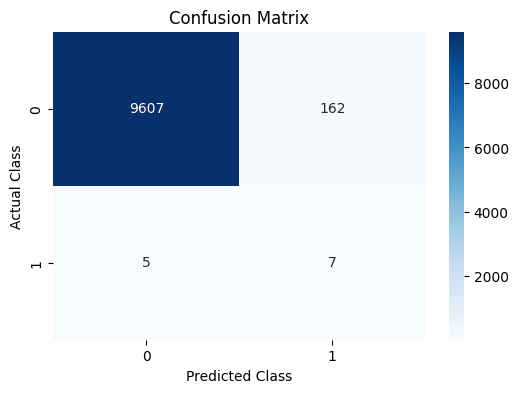

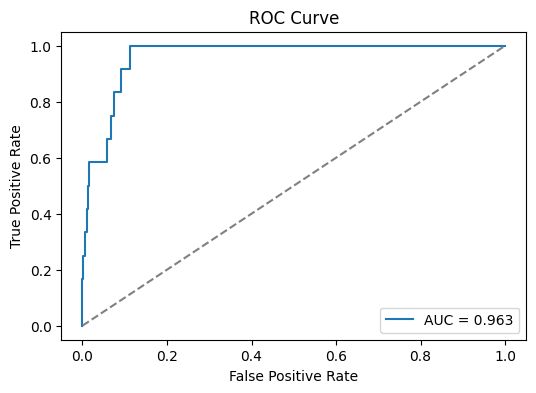

In [33]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = model.predict(X_test_selected)
y_prob = model.predict_proba(X_test_selected)[:, 1]

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix')
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

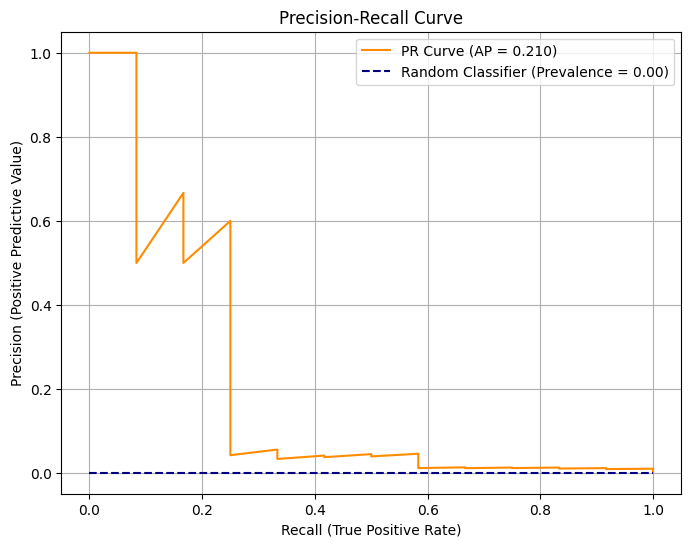

Average Precision (AP) Score: 0.210


In [35]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# --- 2. 獲取 Precision、Recall 和 Thresholds ---
# precision_recall_curve 函數返回 precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# 計算平均精準度 (Average Precision, AP)，這是 PR 曲線的 AUC
ap_score = average_precision_score(y_test, y_prob)

# --- 3. 繪製 PR 曲線 ---
plt.figure(figsize=(8, 6))

# 繪製 PR 曲線
# 注意：X 軸是 Recall，Y 軸是 Precision
plt.plot(recall, precision, label=f'PR Curve (AP = {ap_score:.3f})', color='darkorange')

# 繪製隨機分類器的基準線
# 隨機分類器的 Precision 等於正類別的比例 (Prevalence)
no_skill_prevalence = sum(y_test == 1) / len(y_test)
plt.plot([0, 1], [no_skill_prevalence, no_skill_prevalence], linestyle='--', color='navy', label=f'Random Classifier (Prevalence = {no_skill_prevalence:.2f})')


plt.xlabel('Recall (True Positive Rate)') # X 軸是召回率
plt.ylabel('Precision (Positive Predictive Value)') # Y 軸是精準率
plt.title('Precision-Recall Curve') # 圖表標題
plt.legend(loc='best') # 放置圖例在最佳位置
plt.grid(True) # 顯示網格
plt.show()

print(f"Average Precision (AP) Score: {ap_score:.3f}")

SMOTE + Feature Selection with XGB

--- Starting XGBoost Feature Selection ---

Fitting XGBoost selector model...


/Users/fangilin/anaconda3/envs/myenv/lib/python3.8/site-packages/xgboost/core.py:158: UserWarning: [22:28:24] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost selector model fitted.

Feature Importances (Top 20):
                feature  importance
216  dummy_mrct_missing    0.218884
111          dummy_1300    0.046736
29                 ivpt    0.046420
180    dummy_at_missing    0.036113
68              citotal    0.034005
103                year    0.032749
178   dummy_act_missing    0.027334
164          dummy_7300    0.025612
22                intan    0.025234
161          dummy_6700    0.023491
30                 ivst    0.022529
0          dummy_costat    0.020810
87                 revt    0.019761
90                  txt    0.017812
97                 xopr    0.017082
8                   dlc    0.016801
6                   ceq    0.016503
21                icapt    0.015757
5                    at    0.015679
53                 rvdt    0.015233


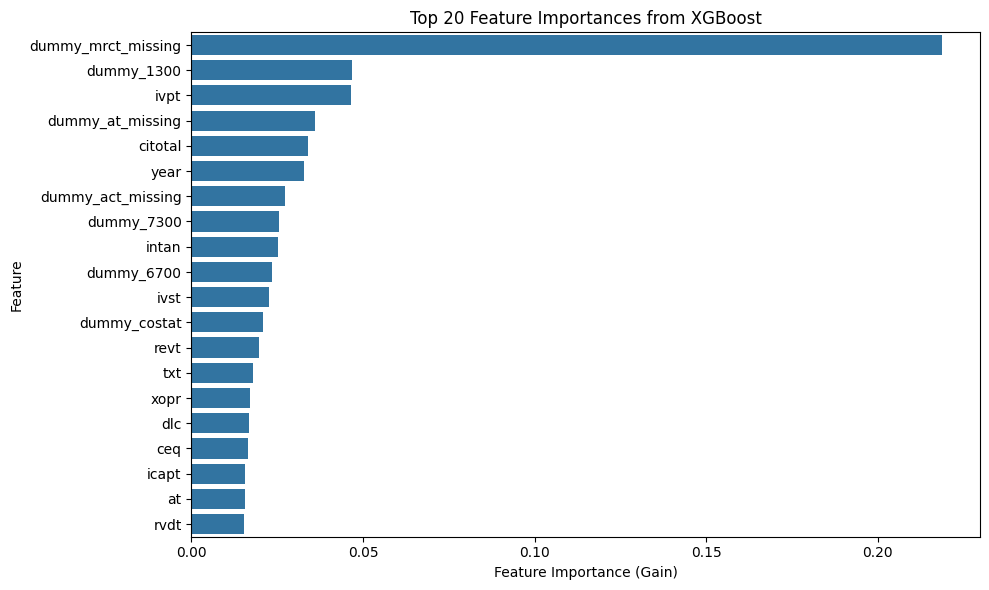


Number of features selected by XGBoost: 129
Selected features: ['dummy_mrct_missing', 'dummy_1300', 'ivpt', 'dummy_at_missing', 'citotal', 'year', 'dummy_act_missing', 'dummy_7300', 'intan', 'dummy_6700', 'ivst', 'dummy_costat', 'revt', 'txt', 'xopr', 'dlc', 'ceq', 'icapt', 'at', 'rvdt', 'tstk', 'dummy_2800', 'ppegt', 'xint', 'dummy_6000', 'pstk', 'dummy_3800', 'xagt', 'act', 'rect', 'dummy_delist', 'dummy_3600', 'xlr', 'dltt', 'dummy_invt_missing', 'txndb', 'dummy_xint_missing', 'lct', 'idit', 'aco', 'mrct', 'lo', 'dummy_3500', 'dvt', 'dummy_4800', 'dummy_4900', 'dummy_5800', 'ppent', 'dummy_5000', 'lt', 'dummy_7900', 'dummy_dptc_missing', 'dummy_8700', 'dummy_3400', 'dummy_4500', 'dummy_5200', 'dummy_5900', 'invt', 'lco', 'dummy_dltt_missing', 'dummy_aco_missing', 'dummy_istm_missing', 'dummy_7800', 'dummy_isut_missing', 'dummy_ivpt_missing', 'dummy_ivst_missing', 'dummy_lcabg_missing', 'dummy_8100', 'dummy_9900', 'dummy_acoxar_missing', 'dummy_7600', 'dummy_lcat_missing', 'dummy_lc

In [37]:
import pandas as pd
import numpy as np
from xgboost import XGBClassifier
import matplotlib.pyplot as plt

# 假設 X_res_scaled, y_res, X_test_scaled 已經準備就緒
# 假設 X (原始DataFrame) 仍然可用，且 X.columns 包含原始特徵名稱

# --- XGBoost for Feature Selection ---
print("--- Starting XGBoost Feature Selection ---")

# 1. 初始化一個 XGBoost 模型用於特徵重要性評估
# 這個模型不需要是最終用於預測的模型，但應具有合理的參數
# 這裡使用一些預設值，您可以根據需要進行調整
xgb_selector = XGBClassifier(
    n_estimators=100,      # 樹的數量
    learning_rate=0.1,     # 學習率
    max_depth=3,           # 樹的最大深度，較淺的樹有助於穩定性
    use_label_encoder=False, # 抑制舊版本XGBoost的警告
    eval_metric='logloss', # 評估指標
    random_state=42
)

# 2. 在已經過 SMOTE 和標準化的訓練數據上訓練 XGBoost 模型
# 訓練後，模型將計算每個特徵的重要性
print("\nFitting XGBoost selector model...")
xgb_selector.fit(X_res_scaled, y_res)
print("XGBoost selector model fitted.")

# 3. 獲取特徵重要性
# 預設情況下，feature_importances_ 使用 'gain' (分裂後損失的平均減少量)
# 您也可以通過 xgb_selector.get_booster().get_score(importance_type='weight') 等方式獲取其他類型的重要性
feature_importances = xgb_selector.feature_importances_
feature_names = X.columns # 獲取原始特徵名稱

# 將特徵名稱和重要性配對，並按重要性降序排列
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importances
})
importance_df = importance_df.sort_values(by='importance', ascending=False)

print("\nFeature Importances (Top 20):")
print(importance_df.head(20))

# 可視化特徵重要性 (可選)
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=importance_df.head(20))
plt.title('Top 20 Feature Importances from XGBoost')
plt.xlabel('Feature Importance (Gain)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# 4. 根據重要性選擇特徵
# 有兩種常見方法：
#   a) 選擇前 N 個特徵 (常用)
#   b) 設定一個重要性閾值，選擇所有重要性高於該閾值的特徵

# --- 方法 a): 選擇前 N 個特徵 ---
num_features_to_select = 129 # 這裡設定您希望選擇的特徵數量
selected_features_xgb = importance_df.head(num_features_to_select)['feature'].tolist()

# --- 方法 b): 選擇重要性高於閾值的特徵 (另一種選擇) ---
# importance_threshold = 0.005 # 這裡設定您希望的閾值
# selected_features_xgb = importance_df[importance_df['importance'] > importance_threshold]['feature'].tolist()


print(f"\nNumber of features selected by XGBoost: {len(selected_features_xgb)}")
print(f"Selected features: {selected_features_xgb}")

# 5. 創建布林遮罩並縮減數據
# 確保遮罩的順序與原始數據的列順序一致
selected_mask_xgb = X.columns.isin(selected_features_xgb)

X_res_selected = X_res_scaled[:, selected_mask_xgb]
X_test_selected = X_test_scaled[:, selected_mask_xgb]

print(f"\nShape of X_res_selected after XGBoost feature selection: {X_res_selected.shape}")
print(f"Shape of X_test_selected after XGBoost feature selection: {X_test_selected.shape}")

print("\n--- XGBoost Feature Selection Complete ---")

In [39]:
# 建立模型
from sklearn.linear_model import LogisticRegression
model_xgb = LogisticRegression(max_iter=1000)
model_xgb.fit(X_res_selected, y_res)

LogisticRegression(max_iter=1000)


Accuracy: 0.9732133728657602
AUC: 0.9433070597468182

Classification Report:
               precision    recall  f1-score   support

           0     0.9995    0.9737    0.9864      9769
           1     0.0265    0.5833    0.0507        12

    accuracy                         0.9732      9781
   macro avg     0.5130    0.7785    0.5186      9781
weighted avg     0.9983    0.9732    0.9853      9781



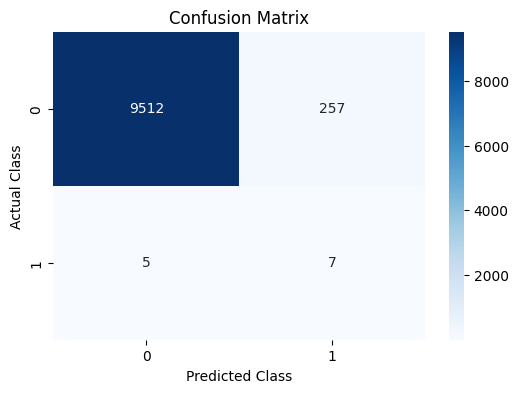

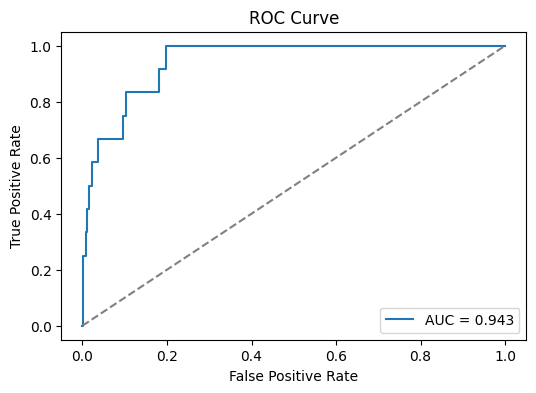

In [41]:
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = model_xgb.predict(X_test_selected)
y_prob = model_xgb.predict_proba(X_test_selected)[:, 1]

print("\nAccuracy:", accuracy_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))
print("\nClassification Report:\n", classification_report(y_test, y_pred, digits=4))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')
plt.title('Confusion Matrix')
plt.show()

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_prob):.3f}")
plt.plot([0,1],[0,1],'--',color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

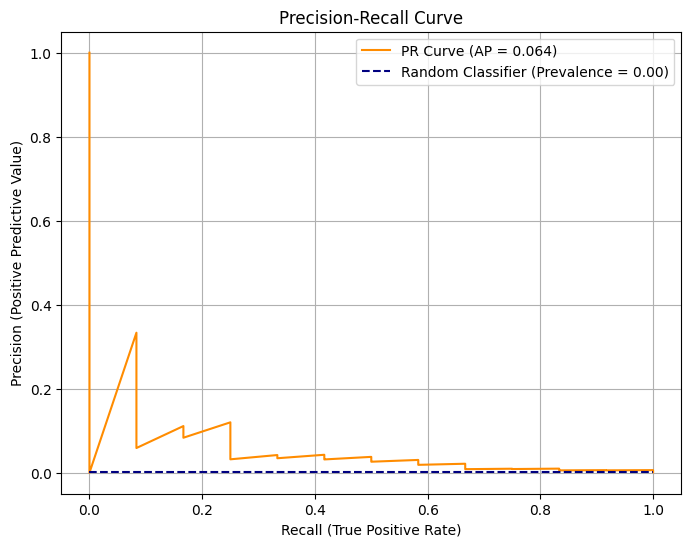

Average Precision (AP) Score: 0.064


In [43]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# --- 2. 獲取 Precision、Recall 和 Thresholds ---
# precision_recall_curve 函數返回 precision, recall, thresholds
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

# 計算平均精準度 (Average Precision, AP)，這是 PR 曲線的 AUC
ap_score = average_precision_score(y_test, y_prob)

# --- 3. 繪製 PR 曲線 ---
plt.figure(figsize=(8, 6))

# 繪製 PR 曲線
# 注意：X 軸是 Recall，Y 軸是 Precision
plt.plot(recall, precision, label=f'PR Curve (AP = {ap_score:.3f})', color='darkorange')

# 繪製隨機分類器的基準線
# 隨機分類器的 Precision 等於正類別的比例 (Prevalence)
no_skill_prevalence = sum(y_test == 1) / len(y_test)
plt.plot([0, 1], [no_skill_prevalence, no_skill_prevalence], linestyle='--', color='navy', label=f'Random Classifier (Prevalence = {no_skill_prevalence:.2f})')


plt.xlabel('Recall (True Positive Rate)') # X 軸是召回率
plt.ylabel('Precision (Positive Predictive Value)') # Y 軸是精準率
plt.title('Precision-Recall Curve') # 圖表標題
plt.legend(loc='best') # 放置圖例在最佳位置
plt.grid(True) # 顯示網格
plt.show()

print(f"Average Precision (AP) Score: {ap_score:.3f}")